# Modelo Baseline — Credit Scoring

Este notebook tem como objetivo estabelecer um modelo baseline para o problema de classificação de risco de crédito.

A Regressão Logística será utilizada como primeiro modelo por oferecer uma solução simples, interpretável e adequada como referência para comparação com experimentos posteriores.

O baseline será construído utilizando as variáveis originais do conjunto de dados, sem Feature Engineering. Posteriormente, novas variáveis poderão ser avaliadas por meio de experimentos controlados, permitindo verificar se realmente agregam desempenho preditivo.

O conjunto de teste será mantido separado durante o desenvolvimento para reduzir o risco de vazamento de informações e permitir uma avaliação mais confiável da capacidade de generalização do modelo.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from credit_scoring_mlops.data.load_data import load_credit_data
from credit_scoring_mlops.data.validation import validate_dataset

In [3]:
# Carrega o dataset original e executa as validações antes da modelagem.

df = load_credit_data()

validation_report = validate_dataset(df)

print(validation_report)
print(f"\nDimensões do dataset: {df.shape}")

df.head()

{'is_empty': False, 'rows': 1000, 'columns': 21, 'missing_values': 0, 'duplicate_rows': 0}

Dimensões do dataset: (1000, 21)


,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,guarantors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telef,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


## Preparação dos Dados

Nesta etapa, o conjunto de dados é preparado para a construção do modelo baseline.

O objetivo inicial é construir uma Regressão Logística utilizando as variáveis originais do dataset, antes da aplicação de Feature Engineering. Isso permitirá estabelecer uma referência de desempenho para os experimentos posteriores.

No dataset original, a variável alvo `credit_risk` possui a seguinte codificação:

- `0` = mau risco de crédito
- `1` = bom risco de crédito

In [4]:
# Separa as variáveis explicativas (X) da variável alvo (y).

X = df.drop(columns="credit_risk")
y = df["credit_risk"]

print(f"Dimensões de X: {X.shape}")
print(f"Dimensões de y: {y.shape}")

Dimensões de X: (1000, 20)
Dimensões de y: (1000,)


In [5]:
# Verifica a quantidade e a proporção de clientes em cada classe do target.

target_distribution = pd.DataFrame(
    {
        "quantidade": y.value_counts().sort_index(),
        "proporcao": y.value_counts(normalize=True).sort_index(),
    }
)

target_distribution

,quantidade,proporcao
credit_risk,,
0,300,0.3
1,700,0.7


In [6]:
# Recodifica o target para que 1 represente o evento de interesse:
# 1 = mau risco de crédito e 0 = bom risco de crédito.

y_model = y.map({0: 1, 1: 0})

# Confere a nova distribuição da variável alvo.
y_model.value_counts().sort_index()

credit_risk
0    700
1    300
Name: count, dtype: int64

In [7]:
# Divide os dados em treino e teste preservando a proporção
# de bons e maus riscos existente no dataset original.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model,
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (800, 20)
X_test:  (200, 20)
y_train: (800,)
y_test:  (200,)


## Pré-processamento

As variáveis são separadas entre numéricas e categóricas para aplicação
das transformações adequadas antes do treinamento do modelo baseline.

Nesta etapa são utilizadas apenas as features originais do dataset,
sem criação de novas variáveis.

In [8]:
# Define as variáveis numéricas que serão utilizadas no modelo baseline.
numeric_features = [
    "duration_months",
    "credit_amount",
    "age",
]

# Define as variáveis categóricas representadas por códigos numéricos no dataset.
categorical_features = [
    column for column in X_train.columns if column not in numeric_features
]

print(f"Variáveis numéricas ({len(numeric_features)}):")
print(numeric_features)

print(f"\nVariáveis categóricas ({len(categorical_features)}):")
print(categorical_features)

Variáveis numéricas (3):
['duration_months', 'credit_amount', 'age']

Variáveis categóricas (17):
['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment_duration', 'installment_rate', 'personal_status_sex', 'guarantors', 'residence_duration', 'property', 'other_installment_plans', 'housing', 'existing_credits', 'job', 'people_liable', 'telef', 'foreign_worker']


In [10]:
# Cria o pré-processador do baseline:
# padroniza as variáveis numéricas e aplica One-Hot Encoding nas categóricas.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

## Modelo Baseline — Regressão Logística

O primeiro modelo utilizado como baseline será a Regressão Logística.

O pré-processamento e o modelo são integrados em um único `Pipeline`, garantindo que as transformações sejam ajustadas apenas com os dados de treinamento e aplicadas de forma consistente aos dados de teste.

Neste primeiro experimento são utilizadas apenas as variáveis originais do dataset, sem Feature Engineering ou ajuste de hiperparâmetros.

In [12]:
# Cria o pipeline do baseline combinando o pré-processamento
# das features com o modelo de Regressão Logística.

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

baseline_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defau

In [13]:
# Ajusta todo o pipeline utilizando exclusivamente os dados de treinamento.
# O pré-processador aprende apenas com X_train, evitando data leakage.

baseline_pipeline.fit(X_train, y_train)

print("Pipeline baseline treinado com sucesso.")

Pipeline baseline treinado com sucesso.


In [14]:
# Gera as previsões de classe para o conjunto de teste.

y_pred = baseline_pipeline.predict(X_test)

print(f"Quantidade de previsões: {len(y_pred)}")
print(f"Classes previstas: {sorted(set(y_pred))}")

Quantidade de previsões: 200
Classes previstas: [np.int64(0), np.int64(1)]


In [25]:
# Obtém a probabilidade estimada de cada cliente
# pertencer à classe de mau risco (classe 1).
y_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

y_proba[:10]

array([0.30815915, 0.32831163, 0.16197441, 0.17268537, 0.70121808,
       0.01498373, 0.06265311, 0.0786315 , 0.05202344, 0.32881959])

## Avaliação do Modelo Baseline

Nesta etapa avaliamos o desempenho da Regressão Logística no conjunto de teste.

Como o evento de interesse foi definido como `1 = mau risco`, as métricas de precisão, recall e F1-score serão interpretadas com foco na capacidade do modelo de identificar corretamente clientes com maior risco de crédito.

Além das métricas tradicionais, será analisada a matriz de confusão para compreender os tipos de erro cometidos pelo modelo.

In [17]:
# Calcula as principais métricas de classificação do modelo baseline.

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

baseline_metrics

{'accuracy': 0.74,
 'precision': 0.5909090909090909,
 'recall': 0.43333333333333335,
 'f1_score': 0.5,
 'roc_auc': 0.7417857142857143}

In [18]:
# Organiza as métricas em uma tabela para facilitar a comparação entre experimentos.

baseline_metrics_df = (
    pd.DataFrame.from_dict(
        baseline_metrics,
        orient="index",
        columns=["valor"],
    )
    .rename_axis("metrica")
    .reset_index()
)

baseline_metrics_df["valor"] = baseline_metrics_df["valor"].round(3)

baseline_metrics_df

,metrica,valor
0,accuracy,0.740
1,precision,0.591
2,recall,0.433
3,f1_score,0.500
4,roc_auc,0.742


In [19]:
# Calcula a matriz de confusão para analisar os acertos e erros do modelo.

conf_matrix = confusion_matrix(y_test, y_pred)

conf_matrix

array([[122,  18],
       [ 34,  26]])

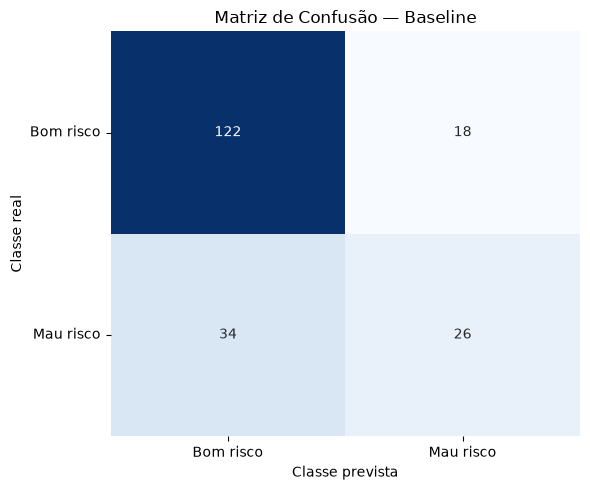

In [24]:
# Exibe a matriz de confusão em formato gráfico.

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax,
)

ax.set_title("Matriz de Confusão — Baseline")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")
ax.set_xticklabels(["Bom risco", "Mau risco"])
ax.set_yticklabels(["Bom risco", "Mau risco"], rotation=0)

plt.tight_layout()
plt.show()

## Conclusão do Modelo Baseline

O modelo baseline de Regressão Logística apresentou desempenho razoável na separação entre clientes de bom e mau risco, com **ROC-AUC de 0,742**.

Entretanto, o principal ponto de atenção está na identificação dos clientes de mau risco. O modelo apresentou **recall de 0,433**, identificando corretamente apenas 43,3% dos clientes dessa classe.

A matriz de confusão mostrou:

* 122 clientes de bom risco classificados corretamente;
* 18 clientes de bom risco classificados incorretamente como mau risco;
* 34 clientes de mau risco classificados incorretamente como bom risco;
* 26 clientes de mau risco classificados corretamente.

Como os falsos negativos representam clientes de mau risco classificados como bons, esse tipo de erro possui maior impacto potencial para o negócio.

O baseline será utilizado como referência para os próximos experimentos. A próxima etapa será avaliar estratégias para aumentar a capacidade de identificação dos clientes de mau risco, mantendo a comparação com este primeiro resultado.


## Experimento 1 — Regressão Logística com balanceamento de classes

O modelo baseline apresentou dificuldade na identificação dos clientes de mau
risco. Neste experimento, será avaliado o impacto do balanceamento de classes
por meio do parâmetro `class_weight="balanced"`.

O objetivo é verificar se o aumento da importância atribuída à classe
minoritária melhora o recall dos clientes de mau risco, sem comprometer
excessivamente as demais métricas.

In [26]:
# Cria uma nova pipeline mantendo o mesmo pré-processamento do baseline
# e adicionando balanceamento automático das classes à Regressão Logística.
balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

# Exibe a estrutura da pipeline balanceada.
balanced_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defau

In [27]:
# Treina a pipeline balanceada utilizando os mesmos dados de treino do baseline.

balanced_pipeline.fit(X_train, y_train)

print("Pipeline balanceada treinada com sucesso.")

Pipeline balanceada treinada com sucesso.


In [28]:
# Gera as previsões de classe para o conjunto de teste.

y_pred_balanced = balanced_pipeline.predict(X_test)

# Obtém a probabilidade de cada cliente pertencer à classe de mau risco.
y_proba_balanced = balanced_pipeline.predict_proba(X_test)[:, 1]

In [29]:
# Calcula as mesmas métricas utilizadas no baseline
# para permitir uma comparação justa entre os experimentos.

balanced_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_balanced),
    "precision": precision_score(y_test, y_pred_balanced),
    "recall": recall_score(y_test, y_pred_balanced),
    "f1_score": f1_score(y_test, y_pred_balanced),
    "roc_auc": roc_auc_score(y_test, y_proba_balanced),
}

balanced_metrics

{'accuracy': 0.685,
 'precision': 0.4810126582278481,
 'recall': 0.6333333333333333,
 'f1_score': 0.5467625899280576,
 'roc_auc': 0.7403571428571429}

In [30]:
# Organiza as métricas do modelo balanceado em uma tabela.

balanced_metrics_df = (
    pd.DataFrame.from_dict(
        balanced_metrics,
        orient="index",
        columns=["valor"],
    )
    .rename_axis("metrica")
    .reset_index()
)

balanced_metrics_df["valor"] = balanced_metrics_df["valor"].round(3)

balanced_metrics_df

,metrica,valor
0,accuracy,0.685
1,precision,0.481
2,recall,0.633
3,f1_score,0.547
4,roc_auc,0.740


In [31]:
# Calcula a matriz de confusão do modelo com classes balanceadas.

balanced_conf_matrix = confusion_matrix(
    y_test,
    y_pred_balanced,
)

balanced_conf_matrix

array([[99, 41],
       [22, 38]])

### Comparação dos Experimentos

A tabela abaixo compara o modelo baseline com a Regressão Logística utilizando
balanceamento de classes. Além das métricas tradicionais, são apresentados
falsos positivos e falsos negativos devido ao impacto desses erros no contexto
de concessão de crédito.

In [32]:
# Cria uma tabela para comparar o desempenho dos experimentos realizados.
model_comparison = pd.DataFrame(
    {
        "modelo": [
            "Logistic Regression - Baseline",
            "Logistic Regression - Balanced",
        ],
        "accuracy": [0.740, 0.685],
        "precision": [0.591, 0.481],
        "recall": [0.433, 0.633],
        "f1_score": [0.500, 0.547],
        "roc_auc": [0.742, 0.740],
        "false_positives": [18, 41],
        "false_negatives": [34, 22],
    }
)

# Exibe a tabela comparativa dos modelos.
model_comparison

,modelo,accuracy,precision,recall,f1_score,roc_auc,false_positives,false_negatives
0,Logistic Regression - Baseline,0.740,0.591,0.433,0.500,0.742,18,34
1,Logistic Regression - Balanced,0.685,0.481,0.633,0.547,0.740,41,22


## Conclusão

O modelo baseline estabeleceu uma referência inicial para o problema de Credit Scoring.

A Regressão Logística sem balanceamento apresentou maior accuracy e precision,
porém identificou apenas 43,3% dos clientes classificados como mau risco.

Ao utilizar `class_weight="balanced"`, o recall aumentou para 63,3% e o número
de falsos negativos caiu de 34 para 22. Em contrapartida, houve aumento dos
falsos positivos e redução da precision e da accuracy.

O ROC-AUC permaneceu praticamente estável entre os experimentos, indicando que
o balanceamento alterou principalmente o comportamento de classificação do
modelo, e não sua capacidade geral de discriminação.

Como falsos negativos representam clientes de mau risco classificados como
bom risco, esse resultado será considerado nos próximos experimentos.

Os próximos passos serão investigar Feature Engineering e novas estratégias
de modelagem, utilizando este baseline como referência de comparação.